# Cours — Apprentissage par renforcement (TP5) 🚑

**Objectif du cours :** comprendre, étape par étape, comment l'agent du TP5
apprend à conduire l'ambulance jusqu'au patient — sans qu'on lui montre
jamais le bon chemin.

**Plan :**

1. Pourquoi un troisième type d'apprentissage ?
2. Le vocabulaire du RL en 4 mots
3. **Mini-exemple résolu à la main** : un couloir 1D
4. La formule de Bellman, décortiquée
5. La stratégie epsilon-greedy
6. Application complète sur la grille 5×5 du TP5
7. Effet des hyperparamètres
8. Pièges classiques et récap

> 💡 Ce notebook est un **complément au TP5**. Tous les concepts seront utilisés
> dans le TP — l'idée ici, c'est de tout voir tourner sur des cas tellement
> petits qu'on peut faire les calculs à la main.

## 1. Pourquoi un troisième type d'apprentissage ?

Jusqu'ici, on a vu deux familles :

| Famille | Données | Question posée à la machine |
|---|---|---|
| **Supervisé** (TP1, TP2) | $(X, y)$ : entrées + bonnes réponses | « Apprends à reproduire les réponses » |
| **Non-supervisé** (TP3) | $X$ seul | « Trouve une structure dans les données » |

L'**apprentissage par renforcement (RL)** répond à un problème différent :

> *Je ne sais pas quelle est la bonne réponse, mais je sais reconnaître quand
> ça se passe bien (récompense positive) ou mal (récompense négative).*

C'est typiquement la situation d'un **agent qui agit dans un environnement** :
un robot, une voiture autonome, une IA qui joue à un jeu vidéo, ou — comme
dans le TP5 — une **ambulance qui doit rejoindre un patient sur une grille**.

L'agent **n'a pas de dataset**. Il n'a que :
- la possibilité d'**essayer des actions**,
- un **signal de récompense** quand il fait quelque chose de bien (ou de mal).

Il doit apprendre **par essai-erreur**.

## 2. La boucle agent ↔ environnement

À chaque pas de temps, il se passe ceci :

```
       ┌──────────────────────┐
       │    Environnement     │
       │   (la grille 5×5)    │
       └──────────────────────┘
            │             ▲
   état s   │             │  récompense r
 (position) │             │  nouvel état s'
            ▼             │
       ┌──────────────────────┐
       │       Agent          │
       │    (l'ambulance)     │
       └──────────────────────┘
                │
            action a
       (haut/bas/gauche/droite)
```

**Les 4 ingrédients à retenir :**

| Symbole | Nom | Dans le TP5 |
|---|---|---|
| $s$ | **état** (state) | la position $(i, j)$ de l'ambulance |
| $a$ | **action** | 0=Haut, 1=Bas, 2=Gauche, 3=Droite |
| $r$ | **récompense** (reward) | $+1$ si on atteint le patient, $-0.5$ si on percute un mur, $0$ sinon |
| $\pi$ | **politique** (policy) | la stratégie « depuis tel état, je fais telle action » |

**Le but du RL :** trouver la politique $\pi^*$ qui **maximise la récompense
totale accumulée**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Reproductibilité (les mêmes tirages aléatoires chez tout le monde)
np.random.seed(42)
random.seed(42)

## 3. Mini-exemple résolu à la main : un couloir 1D

Avant la grille 5×5 du TP, on commence avec **bien plus simple** : un couloir
de 5 cases en ligne.

```
 [ S ] [   ] [   ] [   ] [ G ]
   0     1     2     3     4
```

- L'agent part de la **case 0** (S).
- Le but est la **case 4** (G).
- Deux actions seulement : **← gauche** (0) ou **→ droite** (1).
- Récompenses :
  - $+1$ si on atteint la case 4
  - $0$ partout ailleurs
  - Si on essaie de sortir du couloir (gauche depuis 0, droite depuis 4),
    on reste sur place.

**Pourquoi commencer par cet exemple ?** Parce qu'il est tellement petit
qu'on peut écrire **toute** la Q-Table sur une feuille et faire les calculs
à la main. Tout ce qu'on apprend ici se généralisera directement au TP5.

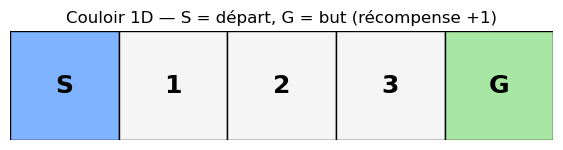

In [2]:
# Définition du couloir 1D
N_CASES = 5
DEPART_1D = 0
BUT_1D = 4
ACTIONS_1D = [0, 1]      # 0 = gauche, 1 = droite
NOMS_ACTIONS_1D = ['←', '→']

def step_1d(s, a):
    '''Effectue l'action a depuis l'état s dans le couloir 1D.
    Retourne (s', r, termine).'''
    if a == 0:        # gauche
        s_prime = max(0, s - 1)
    else:             # droite
        s_prime = min(N_CASES - 1, s + 1)

    if s_prime == BUT_1D:
        return s_prime, 1.0, True
    return s_prime, 0.0, False

# Visualisation
fig, ax = plt.subplots(figsize=(10, 1.6))
for i in range(N_CASES):
    color = '#a8e6a3' if i == BUT_1D else ('#7fb3ff' if i == DEPART_1D else '#f5f5f5')
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='black'))
    label = 'S' if i == DEPART_1D else ('G' if i == BUT_1D else str(i))
    ax.text(i + 0.5, 0.5, label, ha='center', va='center', fontsize=18, fontweight='bold')
ax.set_xlim(0, N_CASES); ax.set_ylim(0, 1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title("Couloir 1D — S = départ, G = but (récompense +1)")
plt.tight_layout(); plt.show()

### 3.1 La Q-Table : ce que l'agent « sait »

L'agent maintient une **table** $Q(s, a)$ qui donne, pour chaque paire
(état, action), une **estimation de la qualité** de cette action depuis cet
état. Concrètement :

> $Q(s, a)$ ≈ « Si je suis dans l'état $s$ et que je joue l'action $a$,
> à quel point ça va bien se passer pour moi à long terme ? »

Au tout début, **l'agent ne sait rien** : on initialise toute la table à 0.

| État | $Q(s, ←)$ | $Q(s, →)$ |
|---|---|---|
| 0 | 0.0 | 0.0 |
| 1 | 0.0 | 0.0 |
| 2 | 0.0 | 0.0 |
| 3 | 0.0 | 0.0 |
| 4 | — (état terminal) | — |

L'agent va remplir cette table progressivement, par essai-erreur.

In [3]:
# Initialisation de la Q-Table pour le couloir 1D
def init_q_1d():
    return {s: [0.0, 0.0] for s in range(N_CASES) if s != BUT_1D}

Q = init_q_1d()
print("Q-Table initiale :")
print(f"{'État':<6}{'Q(s,←)':<10}{'Q(s,→)':<10}")
for s, vals in Q.items():
    print(f"{s:<6}{vals[0]:<10.2f}{vals[1]:<10.2f}")

Q-Table initiale :
État  Q(s,←)    Q(s,→)    
0     0.00      0.00      
1     0.00      0.00      
2     0.00      0.00      
3     0.00      0.00      


### 3.2 Premier épisode — un pas à la main

L'agent commence en case 0. Supposons qu'il choisisse l'action **→** (droite).

**Étape 1 — Exécuter l'action :**

- État courant : $s = 0$
- Action choisie : $a = →$
- Nouvel état : $s' = 1$
- Récompense reçue : $r = 0$ (on n'est pas encore au but)
- Terminé ? Non.

**Étape 2 — Mettre à jour la Q-Table** avec la **formule de Bellman** :

$$Q(s, a) \;\leftarrow\; Q(s, a) \;+\; \alpha \cdot \bigl[\,r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a)\,\bigr]$$

Avec :
- $\alpha = 0.5$ (taux d'apprentissage)
- $\gamma = 0.9$ (facteur d'actualisation)

On calcule, en remplaçant **chaque symbole par sa valeur** :

$$
\begin{aligned}
Q(0, →) &\leftarrow \underbrace{0}_{Q(s,a)} + 0.5 \cdot \Big[\;\underbrace{0}_{r} + 0.9 \cdot \underbrace{\max(0, 0)}_{\max Q(s',a')\;=\;0} - \underbrace{0}_{Q(s,a)}\;\Big]\\
&\leftarrow 0 + 0.5 \cdot 0 \\
&\leftarrow 0
\end{aligned}
$$

🤔 **La case n'a pas bougé.** C'est normal : l'agent vient de faire un pas
« banal » (récompense nulle) vers un état qu'il **ne connaît pas non plus**
(toutes ses Q-valeurs sont encore à 0). Il n'a rien appris.

**La leçon :** au début, **rien ne change** tant que l'agent n'atteint pas
le but **au moins une fois**. C'est le pas qui touche le but qui va déclencher
la première mise à jour intéressante.

### 3.3 Le pas qui change tout : atteindre le but

Continuons. L'agent va vers la droite, vers la droite… jusqu'à arriver en
case 3. Il choisit **→**.

- $s = 3$, $a = →$
- $s' = 4$ (= GOAL !), $r = +1$, terminé.

**Mise à jour de Bellman :**

$$
\begin{aligned}
Q(3, →) &\leftarrow 0 + 0.5 \cdot \Big[1 + 0.9 \cdot 0 - 0\Big]\\
&\leftarrow 0.5
\end{aligned}
$$

🎉 **Première vraie mise à jour !** La case 3, action « → », vaut
maintenant $0.5$. L'agent commence à savoir quelque chose : « être en case 3
et aller à droite, c'est bien ».

**À retenir :** la récompense $+1$ ne se propage pas instantanément
sur toute la table. Elle « entre » par la case juste à côté du but, puis
les mises à jour suivantes la feront remonter, case par case, vers le départ.
C'est ça qu'on va voir maintenant.

### 3.4 Plusieurs épisodes — la propagation des valeurs

On va maintenant lancer plusieurs épisodes complets et **regarder la Q-Table
évoluer** après chaque épisode. On utilise une politique simple : action
totalement aléatoire (epsilon = 1, exploration pure) — pour bien voir comment
les valeurs se propagent.

In [4]:
# Hyperparamètres
ALPHA = 0.5
GAMMA = 0.9
N_EPISODES_1D = 30
MAX_STEPS_1D = 50

# Réinitialiser la Q-Table
Q = init_q_1d()
historique = []   # snapshots de Q-Table après chaque épisode

for ep in range(N_EPISODES_1D):
    s = DEPART_1D
    for _ in range(MAX_STEPS_1D):
        # Politique 100% aléatoire
        a = random.choice(ACTIONS_1D)
        s_prime, r, done = step_1d(s, a)

        # Bellman
        max_next = max(Q[s_prime]) if s_prime in Q else 0.0
        Q[s][a] = Q[s][a] + ALPHA * (r + GAMMA * max_next - Q[s][a])

        s = s_prime
        if done:
            break
    # On stocke un snapshot (copie profonde)
    historique.append({k: list(v) for k, v in Q.items()})

# Affichage des Q-Tables après les épisodes 1, 2, 5, 10, 30
def afficher_qtable_1d(Q, titre):
    print(f"\n=== {titre} ===")
    print(f"{'État':<6}{'Q(s,←)':<10}{'Q(s,→)':<10}{'meilleure':<10}")
    for s in range(N_CASES):
        if s in Q:
            best = NOMS_ACTIONS_1D[int(np.argmax(Q[s]))]
            print(f"{s:<6}{Q[s][0]:<10.3f}{Q[s][1]:<10.3f}{best:<10}")
        else:
            print(f"{s:<6}{'(but)':<10}")

for ep_idx in [0, 1, 4, 9, 29]:
    afficher_qtable_1d(historique[ep_idx], f"Après épisode {ep_idx + 1}")


=== Après épisode 1 ===
État  Q(s,←)    Q(s,→)    meilleure 
0     0.000     0.000     ←         
1     0.000     0.000     ←         
2     0.000     0.000     ←         
3     0.000     0.500     →         
4     (but)     

=== Après épisode 2 ===
État  Q(s,←)    Q(s,→)    meilleure 
0     0.000     0.000     ←         
1     0.000     0.000     ←         
2     0.000     0.225     →         
3     0.000     0.750     →         
4     (but)     

=== Après épisode 5 ===
État  Q(s,←)    Q(s,→)    meilleure 
0     0.379     0.473     →         
1     0.338     0.594     →         
2     0.310     0.780     →         
3     0.456     0.969     →         
4     (but)     

=== Après épisode 10 ===
État  Q(s,←)    Q(s,→)    meilleure 
0     0.652     0.726     →         
1     0.652     0.808     →         
2     0.727     0.898     →         
3     0.807     0.999     →         
4     (but)     

=== Après épisode 30 ===
État  Q(s,←)    Q(s,→)    meilleure 
0     0.656     0.729     → 

**Lecture du tableau :** la valeur $+1$ « entre » d'abord en case 3
(action →), puis se propage à la case 2, puis à la case 1… On voit une
**vague** qui remonte du but vers le départ, atténuée à chaque étape par
le facteur $\gamma = 0.9$.

À convergence, la table devrait ressembler à :

| État | $Q(s, →)$ idéal |
|---|---|
| 3 | $1.0$ |
| 2 | $\gamma \times 1.0 = 0.9$ |
| 1 | $\gamma^2 \times 1.0 = 0.81$ |
| 0 | $\gamma^3 \times 1.0 = 0.729$ |

C'est exactement ça : **plus on est loin du but, plus la valeur est petite**.
L'agent peut alors **suivre les valeurs croissantes** pour atteindre le but.

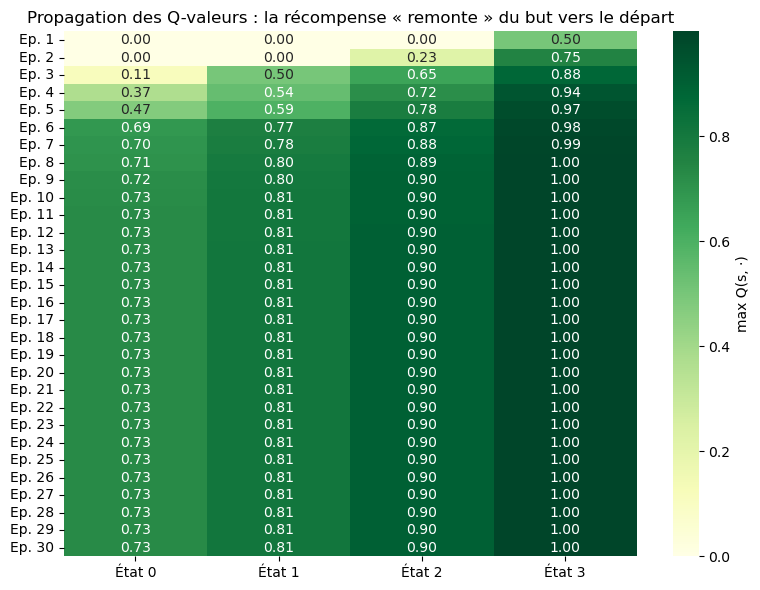

In [5]:
# Visualisation de la propagation : chaque ligne = un épisode,
# chaque colonne = un état, couleur = max Q(s, ·)
matrice = np.zeros((N_EPISODES_1D, N_CASES - 1))
for i, snap in enumerate(historique):
    for s in range(N_CASES - 1):
        matrice[i, s] = max(snap[s])

plt.figure(figsize=(8, 6))
sns.heatmap(matrice, cmap='YlGn', annot=True, fmt='.2f',
            xticklabels=[f'État {s}' for s in range(N_CASES - 1)],
            yticklabels=[f'Ep. {i+1}' for i in range(N_EPISODES_1D)],
            cbar_kws={'label': 'max Q(s, ·)'})
plt.title("Propagation des Q-valeurs : la récompense « remonte » du but vers le départ")
plt.tight_layout(); plt.show()

## 4. La formule de Bellman, décortiquée

$$Q(s, a) \;\leftarrow\; Q(s, a) \;+\; \alpha \cdot \underbrace{\bigl[\,r + \gamma \cdot \max_{a'} Q(s', a') \;-\; Q(s, a)\,\bigr]}_{\text{erreur de prédiction (TD error)}}$$

On peut la **lire en 3 morceaux** :

1. **La cible** $\;r + \gamma \cdot \max_{a'} Q(s', a')$
   → ce qu'on **vient d'observer** : la récompense immédiate + la meilleure
   suite possible (vue par la Q-Table actuelle).

2. **L'erreur de prédiction** $\;\text{cible} - Q(s, a)$
   → l'écart entre ce qu'on **espérait** ($Q(s,a)$) et ce qu'on a
   **vraiment obtenu** (la cible). C'est ce que la machine apprend.

3. **La mise à jour** $\;Q(s, a) \mathrel{+}= \alpha \cdot \text{erreur}$
   → on corrige la table d'une fraction $\alpha$ de l'erreur.

> 🚗 **Analogie GPS :** votre GPS estime « il reste 20 min ». Vous avancez
> et constatez qu'il a fallu 22 min pour faire ce qui était estimé à 20 min.
> Le GPS corrige légèrement sa prédiction la prochaine fois qu'il voit la
> même situation. Le Q-Learning fait exactement ça, à chaque pas.

**Rôle des hyperparamètres :**

| Paramètre | Effet si trop petit | Effet si trop grand |
|---|---|---|
| $\alpha$ (learning rate) | Apprentissage très lent | Q-valeurs instables, oscillent |
| $\gamma$ (discount) | Agent **myope** : ignore le futur | Agent qui considère un horizon très long, convergence plus lente |

## 5. La stratégie epsilon-greedy

Dans la simulation précédente, on jouait **100 % aléatoire**. Ça marche pour
un mini-couloir, mais **pas pour la grille du TP5**. Pourquoi ?

Parce qu'une fois que l'agent **a appris** un bon chemin, on aimerait qu'il
**l'emprunte** plutôt que de continuer à errer aléatoirement.

Mais si on lui dit « prends toujours la meilleure action que tu connais »
**dès le début**, il va se figer sur la première séquence qui marche, même
si elle est mauvaise. Il ne **découvrira jamais** mieux.

**Le dilemme :**

| Comportement | Avantage | Risque |
|---|---|---|
| **Exploiter** (best action) | Profiter de ce qu'on sait | Rater de meilleurs chemins |
| **Explorer** (action aléatoire) | Découvrir | Ne jamais converger |

**La solution epsilon-greedy** est très simple :

> À chaque pas, on tire un nombre aléatoire entre 0 et 1.
> - S'il est **inférieur à $\varepsilon$** → action **aléatoire** (exploration).
> - Sinon → action avec la **plus grande Q-valeur** (exploitation).

En général, on **commence avec $\varepsilon$ élevé** (≈ 0.9) — l'agent ne sait
rien, autant tout essayer — puis on **diminue $\varepsilon$ progressivement**
au fil des épisodes : à mesure que l'agent apprend, il a de moins en moins
besoin d'explorer.

In [6]:
def choisir_action_epsilon_greedy(Q, s, actions, epsilon):
    '''Renvoie une action selon la stratégie epsilon-greedy.'''
    if random.random() < epsilon:
        return random.choice(actions)         # exploration
    return int(np.argmax(Q[s]))                # exploitation

# Démonstration : avec une Q-Table « experte » donnée, regardons la répartition
# des actions choisies pour différents epsilon.
Q_demo = {0: [0.1, 0.7]}   # action 1 (→) est clairement la meilleure
N = 1000

for eps in [0.0, 0.1, 0.5, 0.9]:
    choix = [choisir_action_epsilon_greedy(Q_demo, 0, [0, 1], eps) for _ in range(N)]
    p_droite = sum(choix) / N
    print(f"epsilon = {eps:<4} → action '→' choisie {p_droite*100:5.1f}% du temps")

epsilon = 0.0  → action '→' choisie 100.0% du temps
epsilon = 0.1  → action '→' choisie  96.0% du temps
epsilon = 0.5  → action '→' choisie  73.8% du temps
epsilon = 0.9  → action '→' choisie  54.4% du temps


**Lecture :** avec $\varepsilon = 0$, l'agent prend **toujours** la
meilleure action. Avec $\varepsilon = 0.9$, il l'ignore presque tout le temps
au profit du hasard. Le bon réglage dépend de l'avancement de l'apprentissage.

## 6. Application complète : la grille 5×5 du TP5

On a maintenant tous les ingrédients. On reprend **exactement** l'environnement
du TP5 (mêmes obstacles, mêmes récompenses) et on regarde le Q-Learning
tourner, avec des **snapshots** réguliers de la Q-Table.

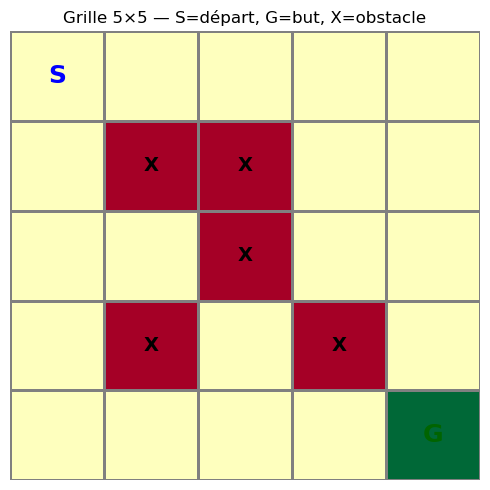

In [7]:
# === Environnement du TP5 (identique au sujet) ===
SIZE = 5
OBSTACLES = [(1,1), (1,2), (2,2), (3,1), (3,3)]
GOAL = (4, 4)
START = (0, 0)
NUM_ACTIONS = 4   # 0=Haut, 1=Bas, 2=Gauche, 3=Droite
NOMS_4 = ['↑', '↓', '←', '→']

def step(state, action):
    x, y = state
    moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    dx, dy = moves[action]
    next_state = (x + dx, y + dy)
    if (next_state[0] < 0 or next_state[0] >= SIZE or
            next_state[1] < 0 or next_state[1] >= SIZE or
            next_state in OBSTACLES):
        return state, -0.5, False
    if next_state == GOAL:
        return next_state, 1.0, True
    return next_state, 0.0, False

# Visualisation de la grille
grid = np.zeros((SIZE, SIZE))
for o in OBSTACLES: grid[o] = -1
grid[GOAL] = 1
plt.figure(figsize=(5, 5))
sns.heatmap(grid, cmap='RdYlGn', linewidths=1, linecolor='gray', cbar=False, vmin=-1, vmax=1)
plt.text(START[1]+0.5, START[0]+0.5, 'S', ha='center', va='center', fontsize=18, fontweight='bold', color='blue')
plt.text(GOAL[1]+0.5,  GOAL[0]+0.5,  'G', ha='center', va='center', fontsize=18, fontweight='bold', color='darkgreen')
for (ox, oy) in OBSTACLES:
    plt.text(oy+0.5, ox+0.5, 'X', ha='center', va='center', fontsize=14, fontweight='bold', color='black')
plt.title("Grille 5×5 — S=départ, G=but, X=obstacle"); plt.axis('off')
plt.tight_layout(); plt.show()

In [8]:
# === Q-Learning sur la grille 5x5 ===
ALPHA = 0.1
GAMMA = 0.9
EPSILON_DEBUT = 0.9
EPSILON_FIN = 0.05
N_EPISODES = 500
MAX_STEPS = 100

# Q-Table : une liste de 4 valeurs pour chaque case non-obstacle
Q = {(i, j): [0.0]*NUM_ACTIONS
     for i in range(SIZE) for j in range(SIZE) if (i, j) not in OBSTACLES}

def epsilon_courant(ep):
    '''Décroissance linéaire de epsilon de DEBUT à FIN sur les N_EPISODES.'''
    frac = ep / max(1, N_EPISODES - 1)
    return EPSILON_DEBUT + (EPSILON_FIN - EPSILON_DEBUT) * frac

snapshots = {}
recompenses_par_ep = []

for ep in range(N_EPISODES):
    s = START
    eps = epsilon_courant(ep)
    total_r = 0.0
    for _ in range(MAX_STEPS):
        # epsilon-greedy
        if random.random() < eps:
            a = random.randint(0, NUM_ACTIONS - 1)
        else:
            a = int(np.argmax(Q[s]))

        s_prime, r, done = step(s, a)
        total_r += r

        # Bellman
        max_next = max(Q[s_prime]) if s_prime in Q else 0.0
        Q[s][a] = Q[s][a] + ALPHA * (r + GAMMA * max_next - Q[s][a])

        s = s_prime
        if done: break

    recompenses_par_ep.append(total_r)
    if (ep + 1) in [1, 10, 50, 200, 500]:
        snapshots[ep + 1] = {k: list(v) for k, v in Q.items()}

print("Entraînement terminé.")
print(f"Récompense moyenne sur les 50 premiers épisodes : {np.mean(recompenses_par_ep[:50]):.3f}")
print(f"Récompense moyenne sur les 50 derniers épisodes : {np.mean(recompenses_par_ep[-50:]):.3f}")

Entraînement terminé.
Récompense moyenne sur les 50 premiers épisodes : -8.090
Récompense moyenne sur les 50 derniers épisodes : 0.800


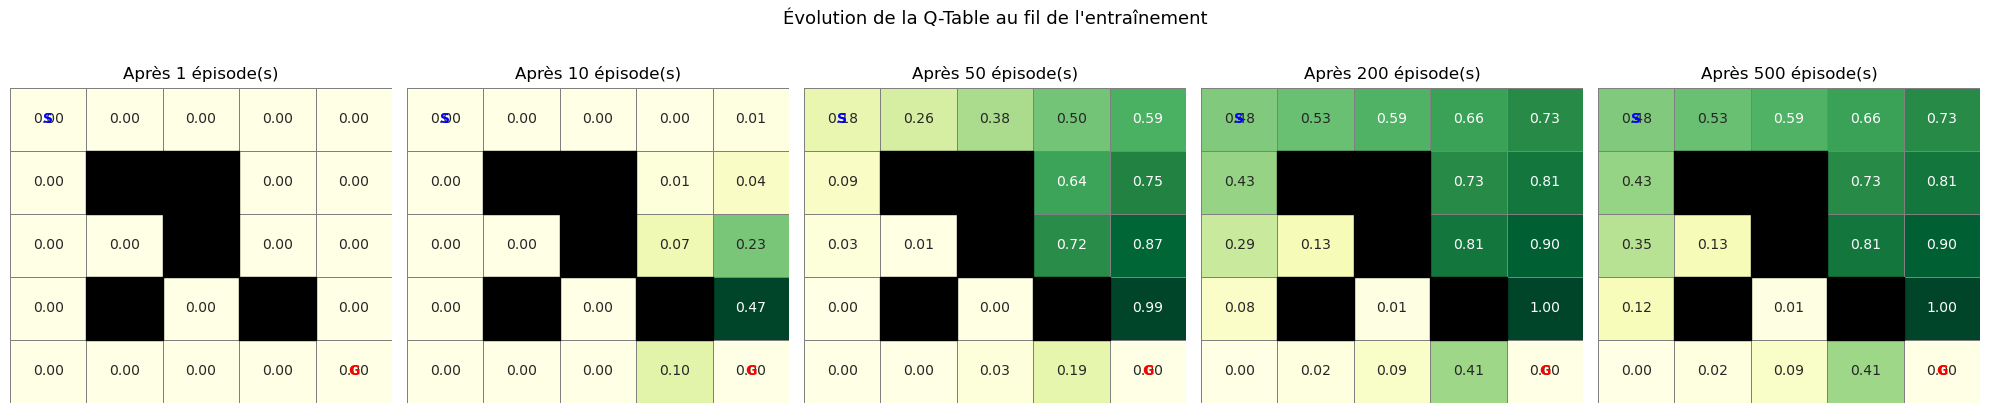

In [9]:
# === Visualiser la Q-Table à différents stades ===
def qtable_to_matrix(Q):
    M = np.full((SIZE, SIZE), np.nan)
    for (i, j), vals in Q.items():
        M[i, j] = max(vals)
    return M

fig, axes = plt.subplots(1, len(snapshots), figsize=(4*len(snapshots), 4))
for ax, (ep, snap) in zip(axes, snapshots.items()):
    M = qtable_to_matrix(snap)
    sns.heatmap(M, ax=ax, cmap='YlGn', annot=True, fmt='.2f',
                cbar=False, linewidths=0.5, linecolor='gray')
    for (ox, oy) in OBSTACLES:
        ax.add_patch(plt.Rectangle((oy, ox), 1, 1, color='black'))
    ax.text(START[1]+0.5, START[0]+0.5, 'S', ha='center', va='center', color='blue', fontweight='bold')
    ax.text(GOAL[1]+0.5,  GOAL[0]+0.5,  'G', ha='center', va='center', color='red',  fontweight='bold')
    ax.set_title(f"Après {ep} épisode(s)")
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Évolution de la Q-Table au fil de l'entraînement", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**Lecture des heatmaps :**

- **Épisode 1 :** quasi tout est encore à 0. L'agent n'a (peut-être) jamais
  trouvé le but.
- **Épisode 10–50 :** une petite tâche verte apparaît autour du but. La
  récompense commence à se propager.
- **Épisode 200–500 :** un **gradient continu** s'est formé entre le départ
  et le but. L'agent peut maintenant trouver son chemin **simplement en
  suivant les valeurs croissantes**.

C'est la signature visuelle d'un Q-Learning qui converge.

In [10]:
# === Vérification : rejouer un épisode en exploitation pure ===
s = START
chemin = [s]
actions = []
for _ in range(MAX_STEPS):
    a = int(np.argmax(Q[s]))
    s_prime, r, done = step(s, a)
    actions.append(NOMS_4[a])
    chemin.append(s_prime)
    s = s_prime
    if done: break

print("Chemin appris (epsilon = 0, exploitation pure) :")
print("  " + " → ".join(str(c) for c in chemin))
print("  Actions : " + "  ".join(actions))
print(f"  Nombre de pas : {len(chemin) - 1}")
print(f"  But atteint : {chemin[-1] == GOAL}")

Chemin appris (epsilon = 0, exploitation pure) :
  (0, 0) → (0, 1) → (0, 2) → (0, 3) → (1, 3) → (1, 4) → (2, 4) → (3, 4) → (4, 4)
  Actions : →  →  →  ↓  →  ↓  ↓  ↓
  Nombre de pas : 8
  But atteint : True


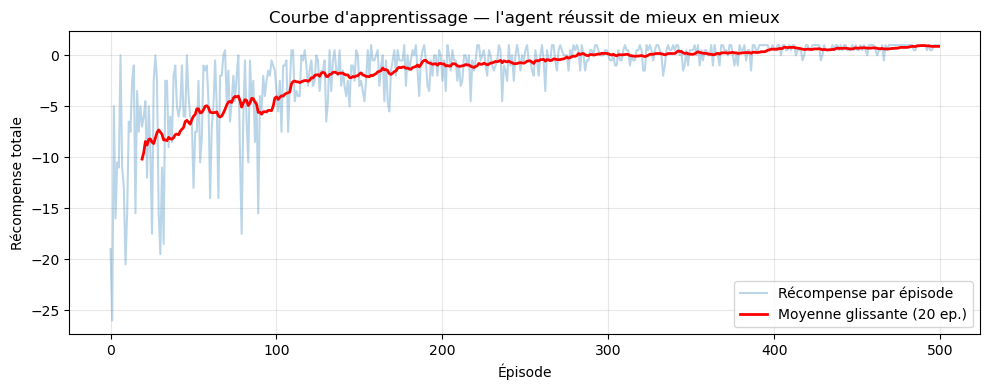

In [11]:
# === Courbe d'apprentissage : récompense par épisode ===
window = 20
moyenne_glissante = np.convolve(recompenses_par_ep, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(recompenses_par_ep, alpha=0.3, label='Récompense par épisode')
plt.plot(range(window-1, len(recompenses_par_ep)), moyenne_glissante,
         color='red', linewidth=2, label=f'Moyenne glissante ({window} ep.)')
plt.xlabel("Épisode"); plt.ylabel("Récompense totale")
plt.title("Courbe d'apprentissage — l'agent réussit de mieux en mieux")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 7. Effet des hyperparamètres

On reprend la grille 5×5 et on fait varier **un seul** hyperparamètre à la
fois pour voir son effet. C'est exactement ce que vos étudiants peuvent
faire en TP en jouant avec les valeurs.

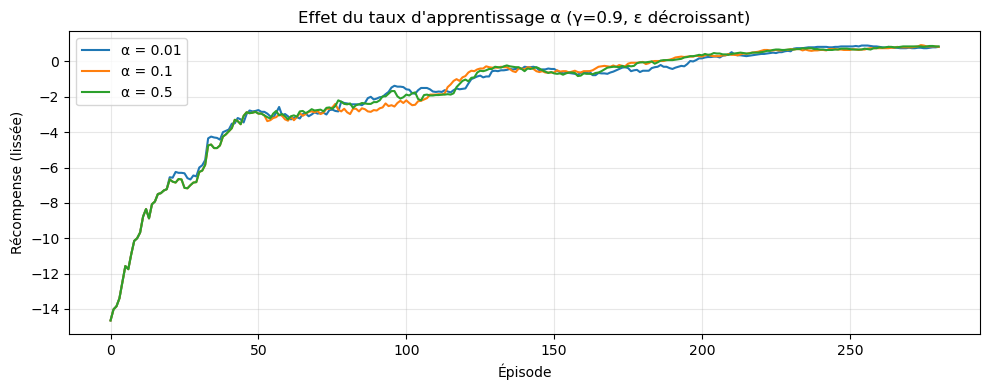

In [12]:
def entrainer(alpha, gamma, eps_debut, eps_fin, n_episodes=300, max_steps=100, seed=0):
    rng = random.Random(seed)
    np_rng = np.random.RandomState(seed)
    Q = {(i, j): [0.0]*NUM_ACTIONS
         for i in range(SIZE) for j in range(SIZE) if (i, j) not in OBSTACLES}
    rewards = []
    for ep in range(n_episodes):
        s = START
        eps = eps_debut + (eps_fin - eps_debut) * (ep / max(1, n_episodes - 1))
        total = 0.0
        for _ in range(max_steps):
            if rng.random() < eps:
                a = rng.randint(0, NUM_ACTIONS - 1)
            else:
                a = int(np.argmax(Q[s]))
            s_prime, r, done = step(s, a)
            total += r
            max_next = max(Q[s_prime]) if s_prime in Q else 0.0
            Q[s][a] += alpha * (r + gamma * max_next - Q[s][a])
            s = s_prime
            if done: break
        rewards.append(total)
    return rewards

def lisser(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# 1) Effet de alpha
plt.figure(figsize=(10, 4))
for a in [0.01, 0.1, 0.5]:
    r = entrainer(alpha=a, gamma=0.9, eps_debut=0.9, eps_fin=0.05)
    plt.plot(lisser(r), label=f'α = {a}')
plt.title("Effet du taux d'apprentissage α (γ=0.9, ε décroissant)")
plt.xlabel("Épisode"); plt.ylabel("Récompense (lissée)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

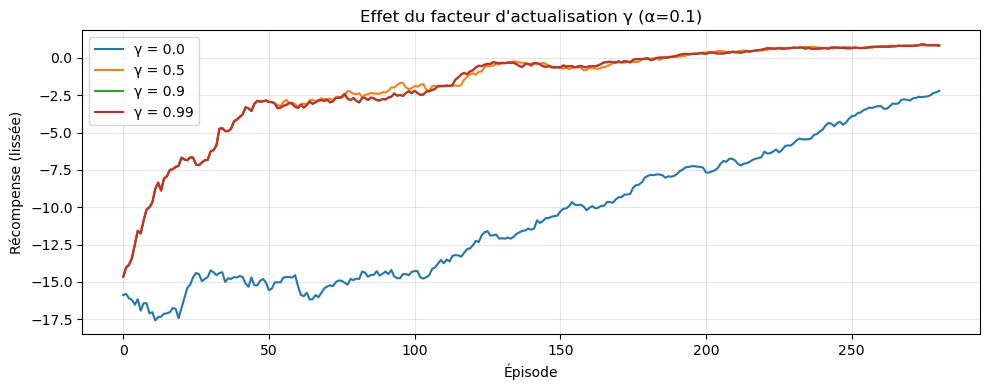

In [13]:
# 2) Effet de gamma
plt.figure(figsize=(10, 4))
for g in [0.0, 0.5, 0.9, 0.99]:
    r = entrainer(alpha=0.1, gamma=g, eps_debut=0.9, eps_fin=0.05)
    plt.plot(lisser(r), label=f'γ = {g}')
plt.title("Effet du facteur d'actualisation γ (α=0.1)")
plt.xlabel("Épisode"); plt.ylabel("Récompense (lissée)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

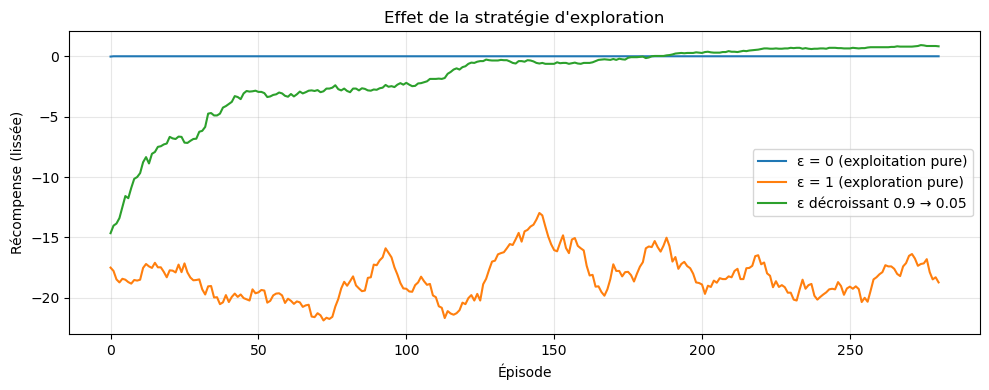

In [14]:
# 3) Effet de la stratégie d'exploration
plt.figure(figsize=(10, 4))
strategies = [
    ("ε = 0 (exploitation pure)",  0.0, 0.0),
    ("ε = 1 (exploration pure)",   1.0, 1.0),
    ("ε décroissant 0.9 → 0.05",   0.9, 0.05),
]
for label, e0, e1 in strategies:
    r = entrainer(alpha=0.1, gamma=0.9, eps_debut=e0, eps_fin=e1)
    plt.plot(lisser(r), label=label)
plt.title("Effet de la stratégie d'exploration")
plt.xlabel("Épisode"); plt.ylabel("Récompense (lissée)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Ce qu'on doit observer :**

- **α trop petit** (0.01) → apprentissage très lent, on plafonne en bas.
- **α trop grand** (0.5) → courbe qui oscille, instable.
- **γ = 0** → l'agent ne voit que la récompense immédiate. Comme la plupart
  des cases donnent $r = 0$, il **n'apprend rien** : la table reste à 0
  partout sauf juste à côté du but.
- **γ proche de 1** → l'agent voit loin, apprend bien, mais la convergence
  peut être plus longue.
- **ε = 0** → l'agent commence avec une Q-Table à 0 et fait toujours
  l'action 0 ; s'il ne tombe pas sur le but par chance, il **n'apprend
  jamais**.
- **ε = 1** → il explore tout le temps, donc apprend, mais **n'exploite
  jamais** ce qu'il sait : sa récompense moyenne reste basse.
- **ε décroissant** → le compromis classique : explorer au début, exploiter
  à la fin.

## 8. Pièges classiques et points de vigilance

| Piège | Symptôme | Cause / fix |
|---|---|---|
| L'agent reste bloqué à 0 partout | Aucun apprentissage visible | Soit ε trop bas (pas d'exploration), soit le but est inatteignable par hasard, soit trop peu d'épisodes |
| Q-valeurs qui explosent | Valeurs énormes, NaN | α trop grand, ou récompenses mal calibrées |
| Bon en entraînement mais mauvais en test (ε=0) | Chemin appris incohérent | ε n'a jamais été assez bas en fin d'entraînement → exploitation jamais éprouvée |
| L'agent fait des allers-retours | Boucle infinie | Pas de pénalité par pas → rien n'incite à finir vite. On peut ajouter $r = -0.01$ par pas |
| Confondre `state` et `next_state` dans Bellman | Apprentissage cassé, lent | $\max Q(s', a')$ utilise le **nouvel** état, pas l'ancien |

---

## Récapitulatif

1. Le RL apprend par **essai-erreur**, à partir d'un signal de **récompense**.
2. Au cœur de l'algorithme : la **Q-Table** $Q(s, a)$ qui estime la qualité
   de chaque (état, action).
3. La **formule de Bellman** met à jour $Q(s, a)$ vers la cible
   $r + \gamma \cdot \max_{a'} Q(s', a')$, à un taux $\alpha$.
4. La récompense **se propage** depuis le but, case par case, atténuée par
   $\gamma$.
5. **Epsilon-greedy** équilibre exploration et exploitation, généralement
   avec un $\varepsilon$ décroissant.
6. Une fois la table apprise, la **politique optimale** consiste simplement à
   prendre $\arg\max_a Q(s, a)$ dans chaque état.

---

**Pour aller au TP5 :** vous avez maintenant tout. Le sujet vous demande
exactement les 6 étapes qu'on vient de voir tourner ici, mais c'est à vous
de les coder.

> 🚑 Bon TP !